<a href="https://colab.research.google.com/github/catarina1532/avcad/blob/main/avcad_ex10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##LDA of Environmental Variables in the EFIplus Dataset

This notebook applies Linear Discriminant Analysis (LDA) to quantitative environmental variables from the EFIplus_medit dataset. The objective is to evaluate whether sites from the Douro, Tejo, Mondego and Minho basins can be discriminated based on environmental conditions, identify the variables contributing most strongly to basin differentiation, and visualize the resulting discriminant space using both static and interactive plots.

###Import packages and load data

***prompt:*** import the EFIplus_medit dataset, load the required libraries for linear discriminant analysis and interactive visualization, and inspect the dataset structure

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

import plotly.express as px

# Load dataset
EFI = pd.read_csv('EFIplus_medit.zip', compression='zip', sep=';')

# Inspect dataset
EFI.head()
EFI.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5011 entries, 0 to 5010
Columns: 164 entries, Site_code to Iberochondrostoma_sp
dtypes: float64(38), int64(120), object(6)
memory usage: 6.3+ MB


The dataset was successfully imported and inspected to verify variable names, data types and the availability of environmental variables and basin classifications required for the LDA analysis.

###Select basins and environmental variables

***prompt:*** filter the dataset to the Douro, Tejo, Mondego and Minho basins and select quantitative environmental variables for linear discriminant analysis

In [2]:
basins = ['Douro', 'Tejo', 'Mondego', 'Minho']

EFI_sub = EFI[
    EFI['Catchment_name'].isin(basins)
].copy()

env_vars = [
    'Altitude',
    'Actual_river_slope',
    'Elevation_mean_catch',
    'prec_ann_catch',
    'temp_ann',
    'temp_jan',
    'temp_jul'
]

EFI_sub = EFI_sub[
    env_vars + ['Catchment_name']
].dropna()

EFI_sub.head()

,Altitude,Actual_river_slope,Elevation_mean_catch,prec_ann_catch,temp_ann,temp_jan,temp_jul,Catchment_name
1,1253,13.406,1603.519424,640.327779,9.3,0.6,18.9,Tejo
2,1155,9.398,1578.678579,633.238847,10.1,1.2,19.6,Tejo
3,1074,8.186,1553.219128,625.841858,10.1,1.2,19.5,Tejo
4,1018,11.736,1539.684999,622.111415,10.3,1.7,20.0,Tejo
5,979,2.670,1493.914010,608.146170,10.6,1.8,20.2,Tejo


Only sites belonging to the four selected river basins were retained. The environmental variables chosen describe topographic and climatic gradients that are expected to contribute to basin differentiation.

###Standardize variables

***prompt:*** standardize the environmental variables prior to linear discriminant analysis to ensure comparability among predictors

In [3]:
X = EFI_sub[env_vars]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

y = EFI_sub['Catchment_name']

Standardization removes differences in measurement scales among variables. This prevents variables with larger numerical ranges from having a disproportionate influence on the discriminant functions.

###Linear Discriminant Analysis

***prompt:*** perform linear discriminant analysis using Catchment_name as the predefined group variable and obtain discriminant scores

In [4]:
lda = LinearDiscriminantAnalysis()

X_lda = lda.fit_transform(X_scaled, y)

lda_df = pd.DataFrame(
    X_lda,
    columns=['LD1', 'LD2', 'LD3']
)

lda_df['Catchment_name'] = y.values

lda_df.head()

,LD1,LD2,LD3,Catchment_name
0,0.760907,1.286815,0.392985,Tejo
1,1.253890,0.970456,-0.065964,Tejo
2,0.356260,1.209093,0.037449,Tejo
3,0.397627,1.015236,0.907298,Tejo
4,0.442558,1.211482,0.377666,Tejo


LDA creates new axes (Linear Discriminants) that maximize separation among the predefined river basins. The first discriminant function explains the largest proportion of between-group variation, while subsequent functions explain progressively smaller amounts.

###LDA biplot

***prompt:*** create a biplot of the first two discriminant functions using Catchment_name as the grouping variable and display environmental variable loadings

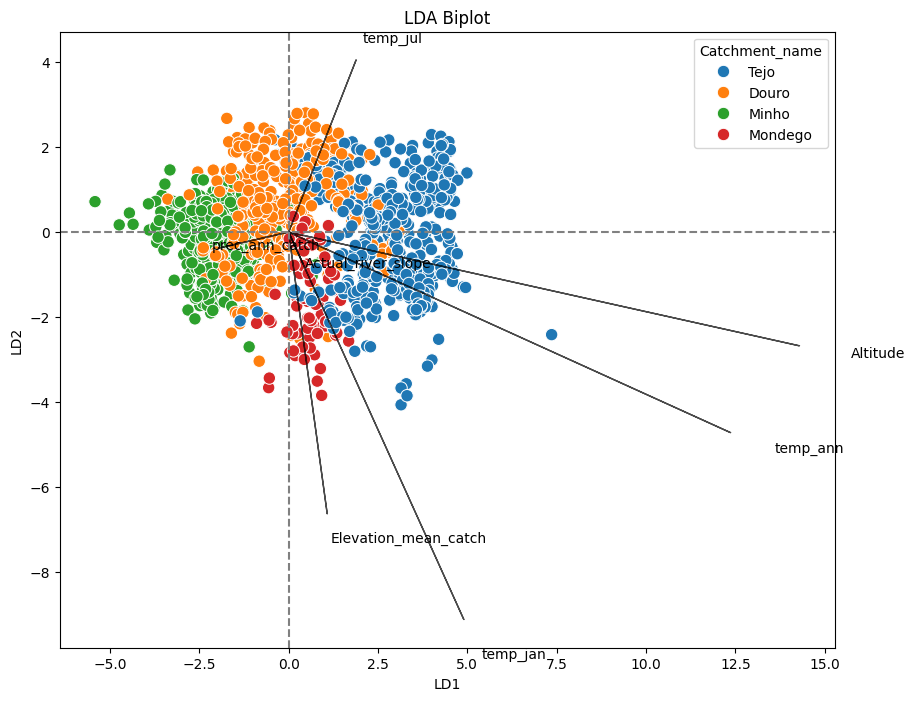

In [5]:
plt.figure(figsize=(10,8))

sns.scatterplot(
    data=lda_df,
    x='LD1',
    y='LD2',
    hue='Catchment_name',
    s=80
)

scaling_factor = 4

for i, var in enumerate(env_vars):
    plt.arrow(
        0,
        0,
        lda.scalings_[i,0] * scaling_factor,
        lda.scalings_[i,1] * scaling_factor,
        color='black',
        alpha=0.7
    )

    plt.text(
        lda.scalings_[i,0] * scaling_factor * 1.1,
        lda.scalings_[i,1] * scaling_factor * 1.1,
        var
    )

plt.axhline(0, color='grey', linestyle='--')
plt.axvline(0, color='grey', linestyle='--')

plt.title('LDA Biplot')
plt.xlabel('LD1')
plt.ylabel('LD2')

plt.show()

The biplot allows visual assessment of how well the four basins are separated by the environmental variables. Distinct clusters indicate that basin groups differ environmentally. Variable vectors indicate which environmental gradients contribute most strongly to basin discrimination and the direction of their influence.

###Discriminant function importance

***prompt:*** calculate the proportion of variance explained by each discriminant function

In [6]:
explained = lda.explained_variance_ratio_

for i, value in enumerate(explained):
    print(f'LD{i+1}: {value:.3f}')

LD1: 0.906
LD2: 0.057
LD3: 0.036


The explained variance ratios indicate the relative importance of each discriminant function. If LD1 explains most of the variation, separation among basins is primarily represented along a single environmental gradient. If LD2 also contributes substantially, basin differentiation occurs along multiple environmental dimensions.

###Interactive LDA scatter plot

***prompt:*** build an interactive scatter plot of the first two discriminant functions coloured by Catchment_name

In [7]:
fig = px.scatter(
    lda_df,
    x='LD1',
    y='LD2',
    color='Catchment_name',
    title='Interactive LDA Plot',
    hover_data=['Catchment_name']
)

fig.show()

The interactive plot facilitates exploration of site distributions in discriminant space. Hovering over points allows identification of individual observations and assessment of basin overlap or separation.

###Interactive LDA plot with site labels

***prompt:*** build an interactive linear discriminant analysis plot displaying site information and basin membership when hovering over observations

In [8]:
lda_df['Site'] = EFI_sub.index

fig = px.scatter(
    lda_df,
    x='LD1',
    y='LD2',
    color='Catchment_name',
    hover_data=['Site'],
    title='Interactive LDA Plot with Site Information'
)

fig.show()

This visualization improves interpretation by linking discriminant scores to specific sampling sites. It can help identify atypical observations, potential outliers or sites that show environmental characteristics similar to those of another basin.

**Conclusion**

Linear Discriminant Analysis successfully identifies environmental gradients that maximize separation among the Douro, Tejo, Mondego and Minho basins.

The first two discriminant functions provide a visual representation of basin differentiation and reveal the environmental variables most responsible for group separation.

Interactive visualizations complement the static biplot by allowing detailed exploration of individual sites and basin membership patterns.

Overall, LDA is a useful supervised ordination technique for investigating how environmental conditions differ among predefined river basins and for identifying the variables that contribute most strongly to those differences.